<a href="https://colab.research.google.com/github/lanile200/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [40]:
# Your Phase 1 solution to the problem goes here.

# Declaration: I completed this version without generative AI.
# Student(s): Lani Le
# Date: 9/2/26

# Question 1a:

# I imported pandas and loaded up the data from the .csv file.
import pandas as pd # importing a package
df = pd.read_csv('airbnb_hw.csv') # putting the source data in df

# Then, I called functions to see what the data in the file actually looks like and check the data.
print(df.shape, '\n') # gives number of rows and columns
print(df.dtypes, '\n') # gives each columns type
df.head() #displays the first rows
print(df['Price'].unique(), '\n')

# Using .dtypes to look at the data types of each column, I saw that the Price variable is of type object and not a numeric value like int.
# Using .unique(), I noticed that for values over 999, there was a comma, which for is not allowed in ints.

# I firstly converted the Price variable into a str type so that I can then get rid of the commas, and then convert the Price variable into an int.
df['Price'] = df['Price'].astype(str) # convert the Price variable from object to string
df['Price'] = df['Price'].replace(',', '', regex=True) # get rid of the comma anywhere in Price
print('Remove commas:\n', df['Price'].unique(), '\n') # verified that the commas are gone
df['Price'] = pd.to_numeric(df['Price'], errors='coerce') # convert the Price variable to a numeric type

# When I first ran the code below, it said there were 181 missing, but now when I run it, there are 0 missing.
df['Price_nan'] = df['Price'].isnull()
print('After coercion:\n', df['Price'].describe(), '\n')
print('Total missings:\n', sum(df['Price_nan']), '\n') # counts how many are missing

df.to_csv('airbnb_hw_clean.csv', index=False) # save a cleaned copy

(30478, 13) 

Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '28

In [41]:
# Question 1b:

# I imported pandas and loaded up the data from the .csv file.
import pandas as pd
import numpy as np
df = pd.read_csv('mn_police_use_of_force.csv')

# Then, I called functions to see what the data in the file actually looks like and check the data.
print(df.shape, '\n') # gives number of rows and columns
print(df.dtypes, '\n')
df.head()
# Using head(), I saw that the data for the subject_injury variable is NaN.

# So then, I decided to see how many are missing, and the code below saw there are 9848.
df['subject_injury_nan'] = df['subject_injury'].isnull()
print('After coercion:\n', df['subject_injury'].describe(), '\n')
print('Total missings:\n', sum(df['subject_injury_nan']), '\n') # counts how many are missing
# Given that there are 12925 rows and I found that 9848 are missing. Therefore the proportion of missing is 9848/12925 or about 76.19%.
# 76.19% is a large percentage of values missing so this is a concern because such a great proportion missing can heavily affect the actual results.

df['new_subject_injury'] = df['subject_injury'].fillna('Missing') # created a new variable that puts 'Missing' for the NaNs
print(pd.crosstab(df['new_subject_injury'], df['force_type'])) # cross-tabulate my cleaned subject_injury variable with the force_type variable
# I noticed a pattern that for a many of the force types, there were more missing than reported yes or reported no. Additionally, I noticed that there were two force types where there were absolutely no reports of yes or no, but there were a huge number of it missing.

df.to_csv('mn_police_use_of_force_clean.csv', index=False) # save a cleaned copy

(12925, 13) 

response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

After coercion:
 count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object 

Total missings:
 9848 

force_type          Baton  Bodily Force  Chemical Irritant  Firearm  \
new_subject_injury                                                    
Missing                 2          7051               1421        0   
No                      0          1093                131        2   
Yes                     2          1286                 41        0   

force_type          Gun Point Display  Improvised Weapon  Less Lethal  \
new_subject_injury       

(7117, 23) 

Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 

Minimum Year:  0.0
Maximum Year:  2026.0

Year
2015.0    143
2017.0    141
2016.0    133
2011.0    128
2014.0    126
         ... 
1977.0     26
1946.0     26
1979.0     25
1940.0     24
1945.0     16
Name: count, Length: 87, dtype: int64


<Axes: xlabel='Year'>

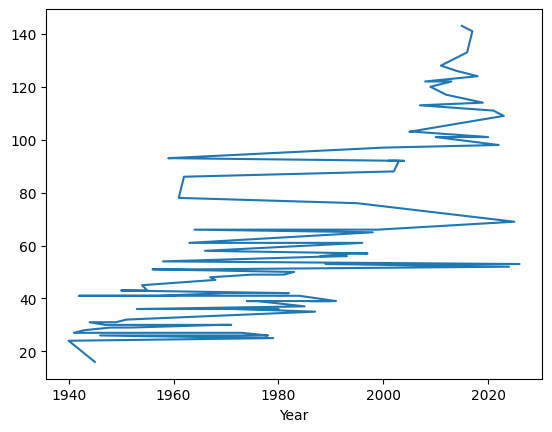

In [42]:
# Question 2:

import pandas as pd #import pandas

df = pd.read_excel('GSAF5.xls') # load data from file

# looking at data
print(df.shape, '\n') # gives number of rows and columns
print(df.dtypes, '\n')
df.head()

# get rid columns with no data
df = df.dropna(how='all', axis=1)

# clean the Year variable
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
print('Minimum Year: ',df['Year'].min())
print('Maximum Year: ',df['Year'].max())
print()
# The years range from 0 to 2026.


df_1940 = df[df['Year'] >= 1940]
attacks_by_year = df_1940['Year'].value_counts()
print(attacks_by_year)
attacks_by_year.plot()
# Based on the chart, attacks look as if they are increasing overtime in recent years.

[nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22.
 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66.
 37. 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64.
 32. 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4.
 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.] 


0       F
1       M
2       M
3       M
4       M
       ..
7112    M
7113    M
7114    M
7115    M
7116    M
Name: Sex, Length: 7117, dtype: object

 Sex Values Before:
['F' 'M' 'M F' '?' 'NAN' 'LLI' 'M X 2' 'N' '.'] 

The proportion of victims that are males is:  0.8747511866482928

0       UNPROVOKED
1       UNPROVOKED
2         PROVOKED
3         PROVOKED
4       UNPROVOKED
           ...    
7112    UNPROVOKED
7113    UNPROVOKED
7114    UNPROVOKED
7115    UNPROVOKED
7116    UNPROVOKED
Name: Type, Length: 7117, dtype: object
The proprtion of unproved attacks is:  0.7394969790642124


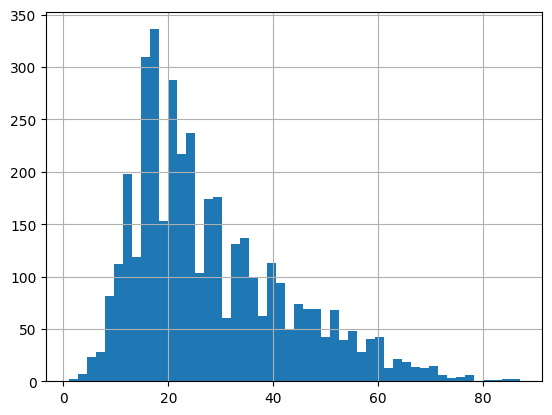

In [49]:
# Question 2 continued:

# cleaning age variable
print(df['Age'].unique(), '\n') # see original values
df['Age'] = df['Age'].astype(str) # converting to type str
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') # converting to numeric type

df['Age'].hist(bins=50) # create the histogram
print()

# cleaning sex variable
print(df['Sex'])
print('\n Sex Values Before:')
print(df['Sex'].unique(), '\n')
df = df.dropna(how='all', axis=1) # drop empty values
df['Sex'] = df['Sex'].astype(str) # converting to type str
df['Sex'] = df['Sex'].astype(str).str.strip().str.upper() # remove space and make uppercase
count = df['Sex'].value_counts()

# calculating proportion
males = count.get('M')
females = count.get('F')
prop_males = males / (males + females)
print('The proportion of victims that are males is: ', prop_males)
print()


print(df['Type'])
df['Type'] = df['Type'].astype(str).str.strip().str.upper() # remove space and make uppercase

def sort_type(value): # function to sort the values in the Type variable
  if 'UNPROVOKED' in value:
    return 'UNPROVOKED'
  elif 'PROVOKED' in value:
    return 'PROVOKED'
  else:
    return 'UNKNOWN'

df['cleaned_Type'] = df['Type'].apply(sort_type)


prop_unprovoked = (df['cleaned_Type'] == 'UNPROVOKED').mean()
print('The proprtion of unproved attacks is: ', prop_unprovoked)
df.to_excel('GSAF5_clean.xlsx', index=False) # save a cleaned copy

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]